🔬 SciPy Tutorial &nbsp;·&nbsp; *Bài 8/11*

[« SciPy Graphs](007_scipy_graphs.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../../README.md) &nbsp;•&nbsp; [SciPy Matlab Arrays »](009_scipy_matlab_arrays.ipynb)

# SciPy Spatial Data

> 📖 **Học song song trên W3Schools:** [scipy_spatial_data.php](https://www.w3schools.com/python/scipy/scipy_spatial_data.php)
>
> 🎯 **Trong bài này:** Working with Spatial Data · Triangulation · Convex Hull · KDTrees · Distance Matrix

## Working with Spatial Data — Dữ liệu không gian

**Dữ liệu không gian** là dữ liệu được biểu diễn trong một không gian hình học, ví dụ các điểm trên hệ toạ độ.

Ta gặp bài toán không gian ở rất nhiều nơi: tìm điểm có nằm trong một vùng không, tìm điểm gần nhất…

SciPy có module `scipy.spatial` với các hàm làm việc với dữ liệu không gian.

## Triangulation — Phép tam giác hoá

**Tam giác hoá** một đa giác là chia đa giác thành nhiều tam giác — dùng để tính diện tích đa giác.

Tam giác hoá **với các điểm** nghĩa là tạo các tam giác có mọi điểm đã cho nằm ở đỉnh tam giác.

Một cách là **Tam giác hoá Delaunay**: `Delaunay()`:

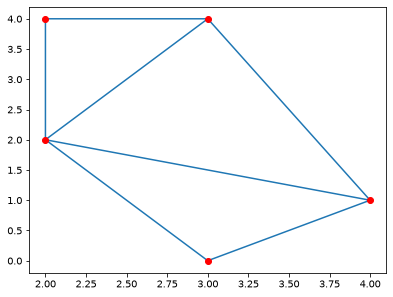

In [1]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

points = np.array([
    [2, 4],
    [3, 4],
    [3, 0],
    [2, 2],
    [4, 1]
])

simplices = Delaunay(points).simplices

plt.triplot(points[:, 0], points[:, 1], simplices)
plt.scatter(points[:, 0], points[:, 1], color='r')

plt.show()

> 📌 Thuộc tính `simplices` là dạng tổng quát của tam giác.

## Convex Hull — Bao lồi

**Bao lồi** là đa giác **nhỏ nhất** bao phủ toàn bộ các điểm đã cho. Dùng `ConvexHull()`:

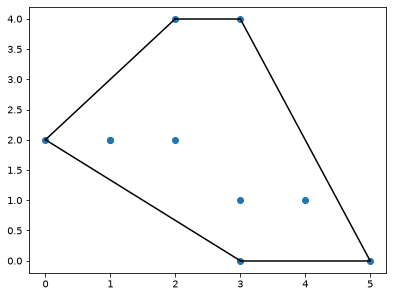

In [2]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

points = np.array([
    [2, 4], [3, 4], [3, 0], [2, 2], [4, 1], [1, 2], [5, 0], [3, 1], [1, 2], [0, 2]
])

hull = ConvexHull(points)
hull_points = hull.simplices

plt.scatter(points[:, 0], points[:, 1])
for simplex in hull_points:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k-')

plt.show()

## KDTrees

**KDTree** là cấu trúc dữ liệu tối ưu cho truy vấn **láng giềng gần nhất**. Ví dụ: với một tập điểm, KDTree giúp tìm nhanh điểm gần một điểm cho trước nhất.

`KDTree()` trả về object KDTree; phương thức `query()` trả về **khoảng cách** tới láng giềng gần nhất và **vị trí** của nó:

In [3]:
from scipy.spatial import KDTree

points = [(1, -1), (2, 3), (-2, 3), (2, -3)]

kdtree = KDTree(points)

res = kdtree.query((1, 1))

print(res)

(2.0, np.int64(0))


## Distance Matrix — Ma trận khoảng cách

Có nhiều thước đo khoảng cách dùng trong khoa học dữ liệu: Euclidean, Cosine… Khoảng cách giữa hai vector có thể không chỉ là độ dài đường thẳng, mà còn là **góc** giữa chúng tính từ gốc toạ độ, hoặc số bước cần đi qua…

### Euclidean Distance — Khoảng cách Euclid

Khoảng cách đường thẳng giữa hai điểm:

In [4]:
from scipy.spatial.distance import euclidean

p1 = (1, 0)
p2 = (10, 2)

res = euclidean(p1, p2)

print(res)

9.219544457292887


### Cityblock Distance (Manhattan Distance) — Khoảng cách Manhattan

Khoảng cách tính khi chỉ được đi theo **4 hướng** (lên, xuống, trái, phải) — như đi trong các dãy phố:

In [5]:
from scipy.spatial.distance import cityblock

p1 = (1, 0)
p2 = (10, 2)

res = cityblock(p1, p2)

print(res)

11


### Cosine Distance — Khoảng cách Cosine

Giá trị dựa trên **cosine của góc** giữa hai điểm A và B:

In [6]:
from scipy.spatial.distance import cosine

p1 = (1, 0)
p2 = (10, 2)

res = cosine(p1, p2)

print(res)

0.019419324309079777


### Hamming Distance — Khoảng cách Hamming

Tỉ lệ các **vị trí khác nhau** giữa hai chuỗi bit — dùng để đo khoảng cách giữa các chuỗi nhị phân:

In [7]:
from scipy.spatial.distance import hamming

p1 = (True, False, True)
p2 = (False, True, True)

res = hamming(p1, p2)

print(res)

0.6666666666666666


---

## 🧠 Ghi nhớ nhanh

> - `Delaunay(points).simplices` → tam giác hoá · `ConvexHull(points)` → bao lồi.
> - `KDTree(points).query(p)` → (khoảng cách, chỉ số) láng giềng gần nhất.
> - Khoảng cách: `euclidean` (đường thẳng) · `cityblock` (Manhattan) · `cosine` (góc) · `hamming` (vị trí khác nhau).

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** Khoảng cách **Manhattan** giữa `(1, 0)` và `(10, 2)` là bao nhiêu?

- **A.** 13
- **B.** 9
- **C.** 9.22
- **D.** 11

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: D** — 11

|10 - 1| + |2 - 0| = 9 + 2 = 11.

</details>

---

[« SciPy Graphs](007_scipy_graphs.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../../README.md) &nbsp;•&nbsp; [SciPy Matlab Arrays »](009_scipy_matlab_arrays.ipynb)